# Logistic Regression Student Activity
This notebook will guide you through:
1. Understanding logistic regression concepts
2. Working with a simple dataset (hours studied vs pass/fail)
3. Training and testing a logistic regression model
4. Interpreting probabilities and decision thresholds
---

## Step 1: Import libraries
We will use NumPy, Pandas, Matplotlib, and scikit-learn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
%matplotlib inline

## Step 2: Create a simple dataset
We will model whether a student passes an exam (1) or not (0) based on hours studied.

In [7]:
data = pd.DataFrame({
    'hours': [1, 2, 3, 4, 5, 6],
    'passed': [0, 0, 0, 1, 1, 1]
})
data

,hours,passed
0,1,0
1,2,0
2,3,0
3,4,1
4,5,1
5,6,1


## Step 3: Visualise the dataset
Make a scatter plot of hours studied vs exam result.

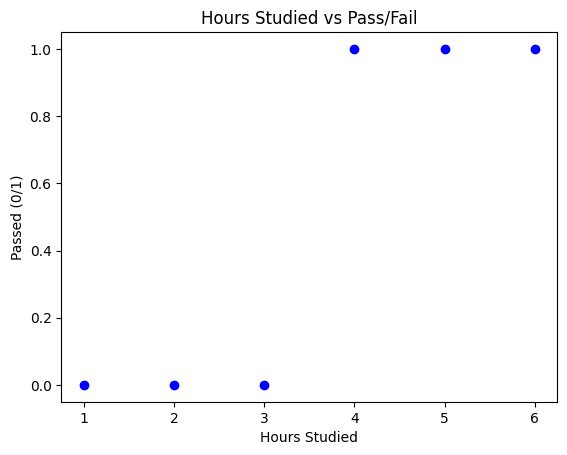

In [8]:
plt.scatter(data['hours'], data['passed'], color='blue')
plt.xlabel('Hours Studied')
plt.ylabel('Passed (0/1)')
plt.title('Hours Studied vs Pass/Fail')
plt.show()

## Step 4: Train a Logistic Regression Model
Fit a logistic regression model to this small dataset.

In [9]:
X = data[['hours']].values
y = data['passed'].values
model = LogisticRegression()
model.fit(X, y)
print('Coefficient:', model.coef_[0][0])
print('Intercept:', model.intercept_[0])

Coefficient: 1.1206952510393666
Intercept: -3.9223038967769632


## Step 5: Plot the sigmoid curve
Use the model to plot the probability of passing as hours studied increases.

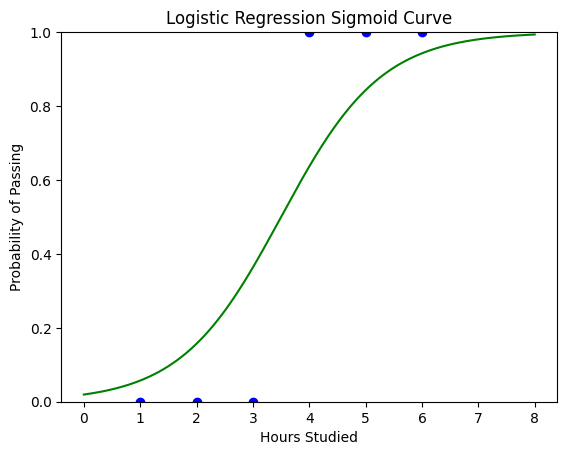

In [10]:
xs = np.linspace(0, 8, 200).reshape(-1, 1)
probs = model.predict_proba(xs)[:, 1]
plt.plot(xs, probs, color='green')
plt.scatter(data['hours'], data['passed'], color='blue')
plt.xlabel('Hours Studied')
plt.ylabel('Probability of Passing')
plt.title('Logistic Regression Sigmoid Curve')
plt.ylim(0, 1)
plt.show()

## Step 6: Make predictions
Predict whether students studying 2, 4, and 6 hours would pass.

In [11]:
new_hours = np.array([[2], [4], [6]])
pred_probs = model.predict_proba(new_hours)[:, 1]
pred_class = (pred_probs >= 0.5).astype(int)
for h, p, c in zip(new_hours.flatten(), pred_probs, pred_class):
    print(f'Hours={h}: probability of pass={p:.2f} → class={c}')

Hours=2: probability of pass=0.16 → class=0
Hours=4: probability of pass=0.64 → class=1
Hours=6: probability of pass=0.94 → class=1


## Student Activity Questions
1. What happens to the probability of passing as hours increase?
2. If we lower the threshold from 0.5 to 0.4, which students would change class?
3. Add a new data point: a student studied 4 hours and passed. Re-train the model. How does the curve change?
4. In real life, when would we want a higher threshold? When would we want a lower threshold?
